# Figure 3: TargetGAN Performance and Synthetic Promoter Evaluation

This notebook generates the panels for **Figure 3**, which evaluate the performance of TargetGAN in generating functional promoters with specified activity levels and assessing their biological naturalness.

The analyses presented in this figure include:

*   **Activity Target Accuracy**: Evaluation of the model's ability to generate promoters that match specific activity targets (Max, 2, 1, 0, -1, -2, -3, -4, Min).
*   **Optimization Process**: Visualization of the iterative optimization process towards target activities.
*   **Robustness Analysis**: Assessment of model stability across multiple independent training runs (seeds).
*   **Sequence Similarity**: 
    *   Correlation analysis of **6-mer frequencies** between Natural Promoters (NPs) and TargetGAN-generated Synthetic Promoters (SPs).
*   **Diversity & Composition**:
    *   Analysis of sequence diversity using **Jaccard Distance** and **Levenshtein Distance**, showing that TargetGAN maintains diversity comparable to WGAN-GP and natural sequences.
    *   **GC Content** distribution comparison among Natural, WGAN-GP, and TargetGAN sequences.

## 3.1. Accuracy of TargetGAN in Generating Activity-Specific Promoters

--- Activity Target Percentage (Seed 2023) ---
Target = Max: 63.6%
Target = 2: 68.1%
Target = 1: 79.8%
Target = 0: 77.4%
Target = -1: 71.0%
Target = -2: 70.8%
Target = -3: 80.7%
Target = -4: 75.4%
Target = Min: 24.9%


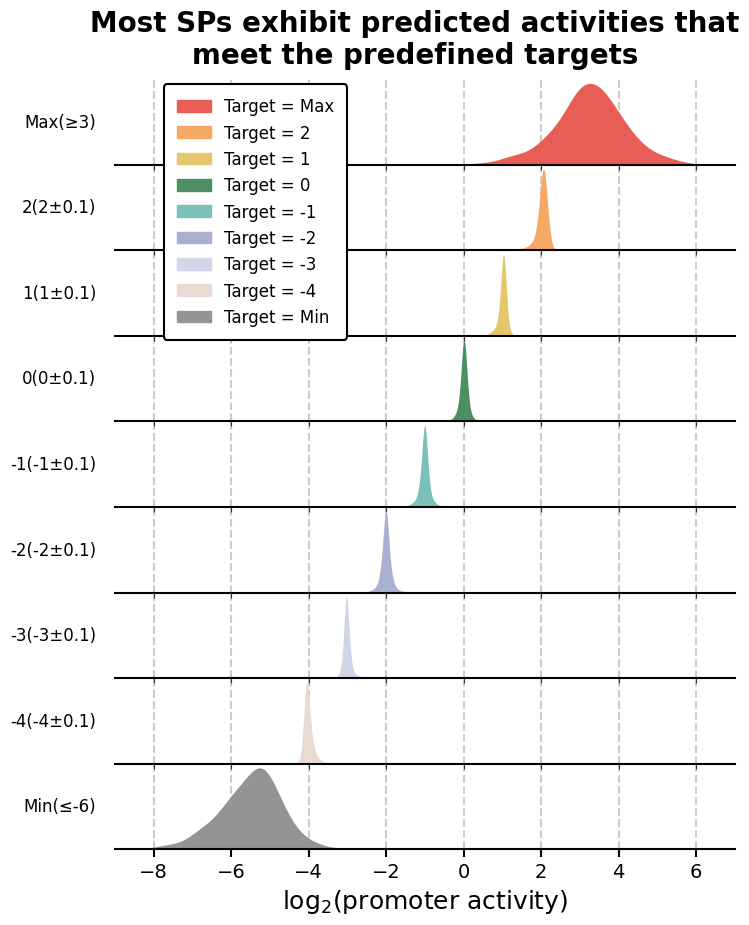

In [4]:
import os
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import tensorflow as tf

# Set TF logger to ERROR only
tf.get_logger().setLevel('ERROR')

import importlib
import utils
importlib.reload(utils)
from utils import one_hot_encode, suppress_tf_warnings

# Double check via utility
suppress_tf_warnings()

# 1. Load Predictor
model_path = '../data/predictor.h5'
if not os.path.exists(model_path):
    model_path = '/home/xlxiang/TargetGAN-main/data/predictor.h5'
model = keras.models.load_model(model_path)

# 2. Configuration
targets_config = [
    ("Max(≥3)", "max", lambda x: x >= 3.0, "Target = Max"),
    ("2(2±0.1)", "2", lambda x: (x >= 1.9) & (x <= 2.1), "Target = 2"),
    ("1(1±0.1)", "1", lambda x: (x >= 0.9) & (x <= 1.1), "Target = 1"),
    ("0(0±0.1)", "0", lambda x: (x >= -0.1) & (x <= 0.1), "Target = 0"),
    ("-1(-1±0.1)", "-1", lambda x: (x >= -1.1) & (x <= -0.9), "Target = -1"),
    ("-2(-2±0.1)", "-2", lambda x: (x >= -2.1) & (x <= -1.9), "Target = -2"),
    ("-3(-3±0.1)", "-3", lambda x: (x >= -3.1) & (x <= -2.9), "Target = -3"),
    ("-4(-4±0.1)", "-4", lambda x: (x >= -4.1) & (x <= -3.9), "Target = -4"),
    ("Min(≤-6)", "min", lambda x: x <= -6.0, "Target = Min")
]

# Custom color palette matching the image
colors = [
    "#E85D56", # Max - Salmon/Red
    "#F6A964", # 2 - Orange
    "#E5C66A", # 1 - Yellow/Gold
    "#4B8F62", # 0 - Green
    "#7AC2B9", # -1 - Teal
    "#AAB0CF", # -2 - Lavender/Grey
    "#D0D5E8", # -3 - Light Blue/Grey
    "#E7DBD3", # -4 - Beige/Grey
    "#949494"  # Min - Grey
]

logs_dir = '../targetgan-logs'
target_seed = '2023'
results = []

# 3. Process Data
print(f"--- Activity Target Percentage (Seed {target_seed}) ---")
for idx, (axis_label, prefix, criteria, legend_label) in enumerate(targets_config):
    folder_name = f"target_{prefix}_seed_{target_seed}"
    file_path = os.path.join(logs_dir, folder_name, 'last_seq.txt')
    
    if not os.path.exists(file_path):
        continue
    
    with open(file_path, 'r') as f:
        sequences = [line.strip() for line in f if line.strip()]
    
    if not sequences:
        continue

    # Predict
    one_hots = np.array([one_hot_encode(s) for s in sequences])
    preds = model.predict(one_hots, verbose=0, batch_size=256).squeeze()
    
    # Calculate Stats
    matches = criteria(preds)
    pct = np.mean(matches) * 100
    
    # Print percentage as requested
    print(f"{legend_label}: {pct:.1f}%")
    
    results.append({
        'data': preds,
        'axis_label': axis_label,
        'legend_label': legend_label,
        'pct': pct,
        'color': colors[idx],
        'target_val': prefix 
    })

# 4. Plotting (Ridge Plot / Joy Plot)
# Use exact spacing hspace=0 to make them touch like the reference
fig, axes = plt.subplots(len(results), 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0})

for i, res in enumerate(results):
    ax = axes[i]
    data = res['data']
    color = res['color']
    
    # KDE Plot
    # Fill opacity 1.0 to match the solid look in "Desired" image
    sns.kdeplot(data, ax=ax, fill=True, color=color, alpha=1.0, linewidth=0, bw_adjust=1.5)
    
    # Grid lines (Vertical only)
    # Using zorder=0 to put grid behind the plot
    for x in range(-8, 8, 2):
        ax.axvline(x, linestyle='--', linewidth=1.5, color='gray', alpha=0.4, zorder=0)
    
    # Adjust axes visibility
    ax.set_facecolor('none')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Bottom spine: Make it black and solid for every track
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    
    # Remove y ticks
    ax.set_yticks([])
    
    # Add Y-label (rows) on the left
    ax.set_ylabel(res['axis_label'], rotation=0, ha='right', va='center', fontsize=12, color='black', labelpad=10)
    
    # Y Label alignment - force it to be horizontal and aligned
    # We use labelpad above to push it out, but consistent alignment across subplots is handled by matplotlib reasonably well
    
    # Limit y-axis per subplot to allow the density to fit nicely
    # We don't want them to be too flat. 
    # Auto-scaling usually works, but ensure no clipping if peaks are high.

# X-axis configuration
axes[-1].set_xlabel('log$_2$(promoter activity)', fontsize=18)
axes[-1].tick_params(axis='x', labelsize=14, length=6, width=1.5)
axes[-1].set_xlim(-9, 7)
# Ensure x-ticks match the grid/image (-8 to 6 usually)
axes[-1].set_xticks(range(-8, 8, 2))

# Overall Title
fig.suptitle('Most SPs exhibit predicted activities that\nmeet the predefined targets', 
             fontsize=20, fontweight='bold', y=0.95)

# Legend
# Create custom handles for the legend
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=res['color'], label=res['legend_label']) for res in results]

# Place legend in the figure coordinates to float over the top-left area
# bbox_to_anchor=(x, y) coordinates are in figure space (0,0 is bottom-left, 1,1 is top-right)
# Adjust these values to position the box correctly over the top subplots
legend = fig.legend(handles=legend_handles, 
                    loc='upper left', 
                    bbox_to_anchor=(0.18, 0.88), # Adjust x, y to fit in the empty space
                    frameon=True, 
                    edgecolor='black', 
                    framealpha=1, 
                    fontsize=12, 
                    labelspacing=0.5,
                    borderpad=0.6)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_boxstyle("Round,pad=0.2") # Optional rounded corners
plt.show()

## 3.2. Visualization of the Iterative Optimization Process

--- Optimization Progress (Seed 2023) ---


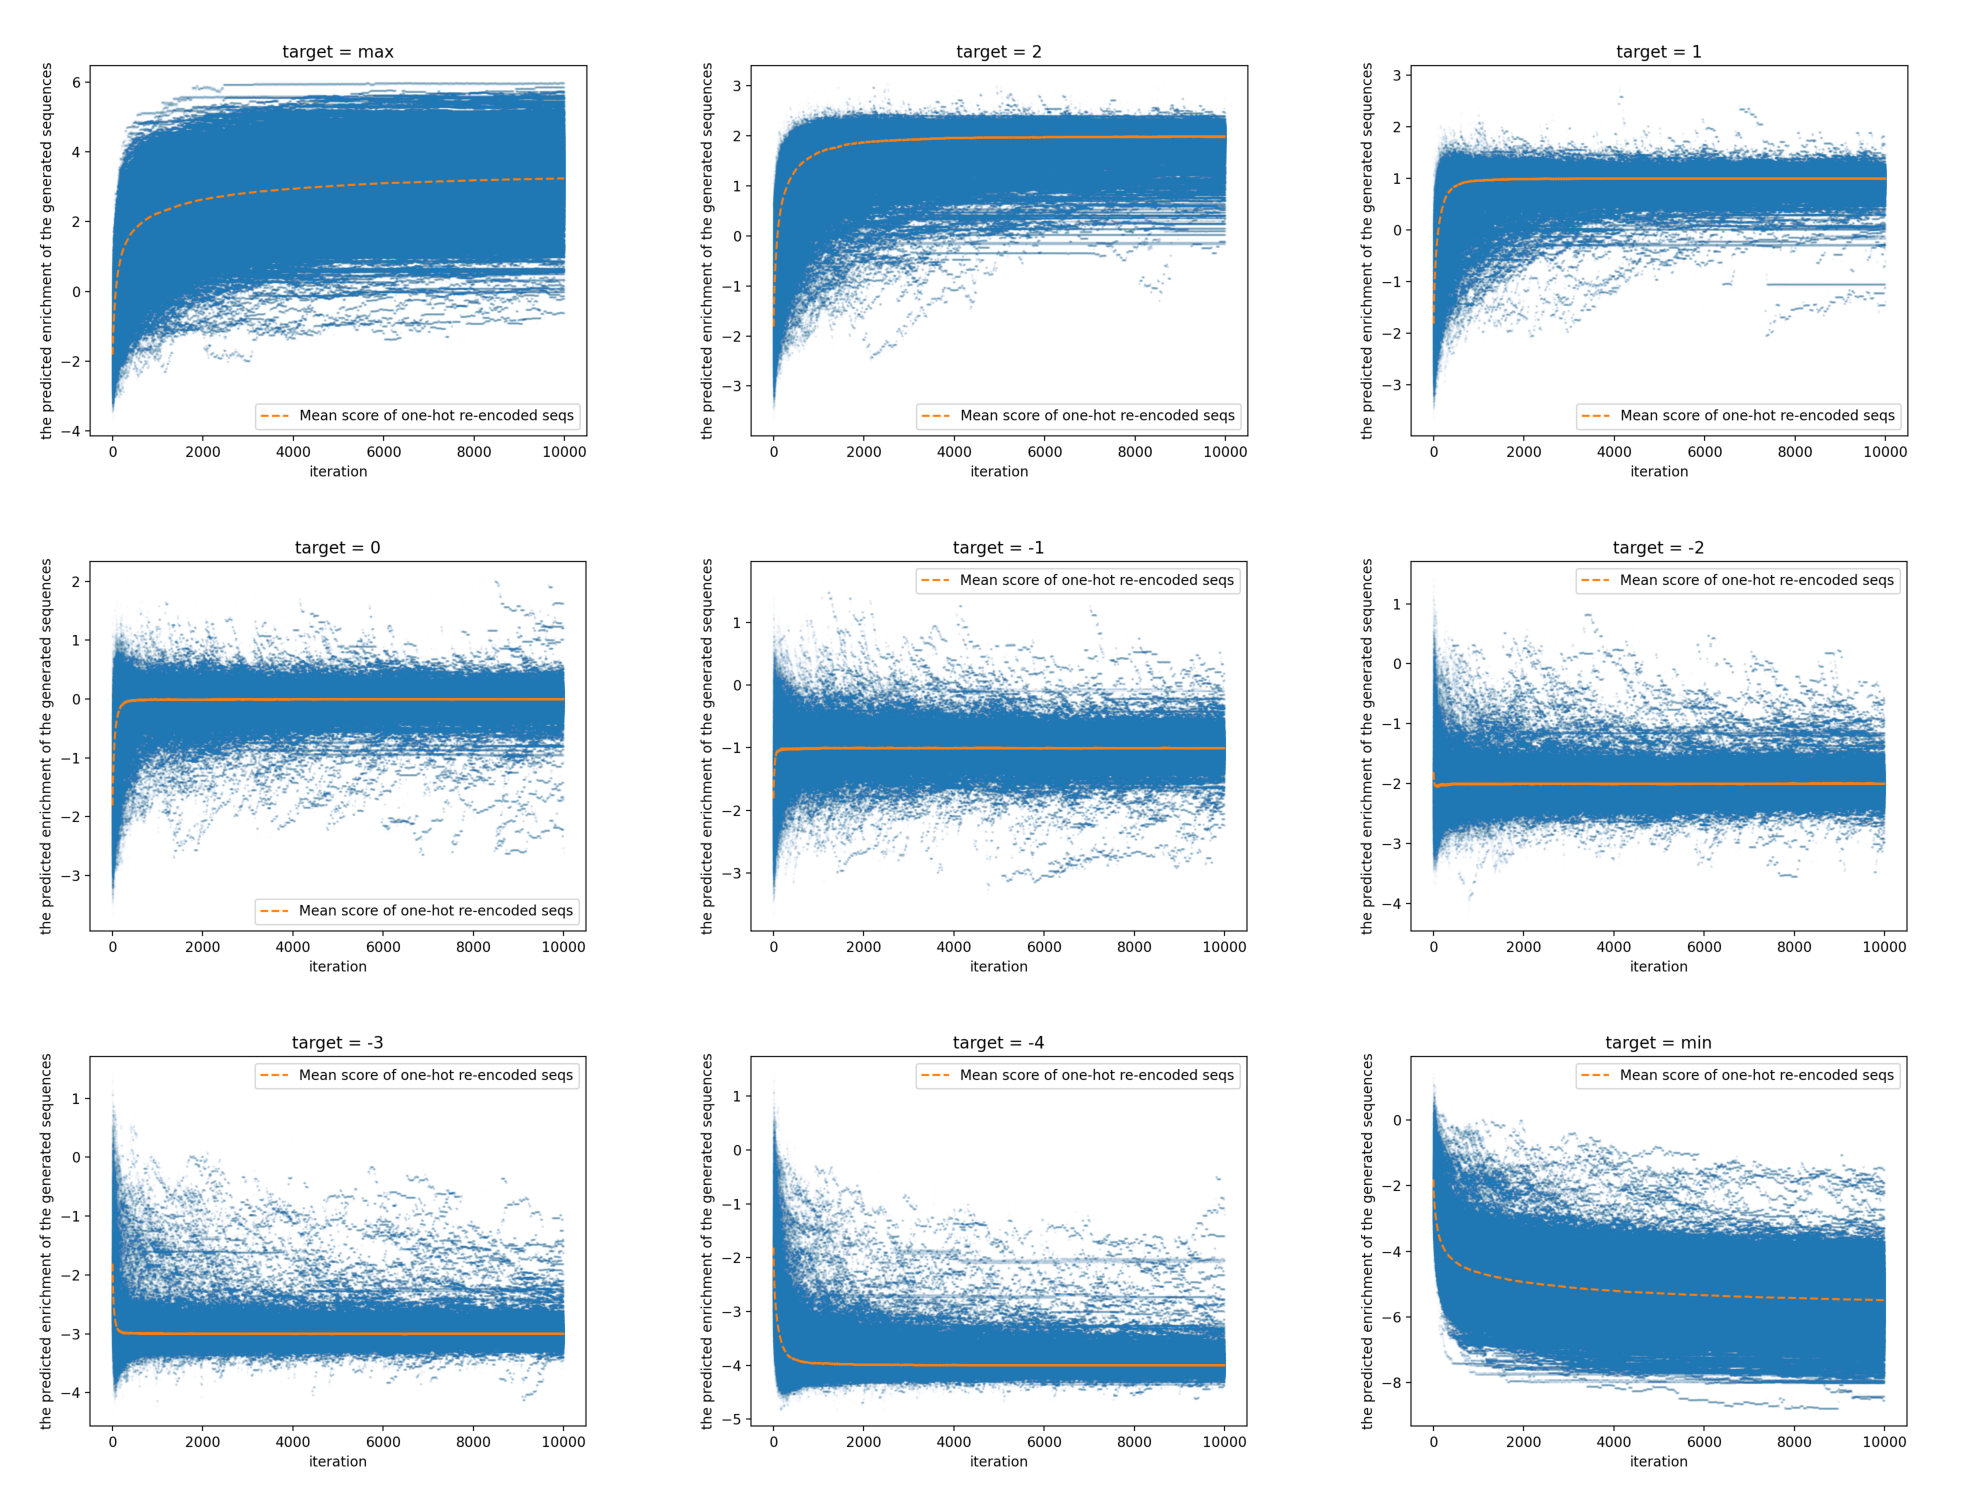

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Define the targets in order
targets_map = [
    ("max", "Target = Max"),
    ("2", "Target = 2"),
    ("1", "Target = 1"),
    ("0", "Target = 0"),
    ("-1", "Target = -1"),
    ("-2", "Target = -2"),
    ("-3", "Target = -3"),
    ("-4", "Target = -4"),
    ("min", "Target = Min")
]
seed = "2023"
logs_dir = "../targetgan-logs"

# Create a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

print(f"--- Optimization Progress (Seed {seed}) ---")

for i, (prefix, label) in enumerate(targets_map):
    # Construct image path
    img_path = os.path.join(logs_dir, f"target_{prefix}_seed_{seed}", "scores_opt.png")
    
    ax = axes[i]
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off') # Turn off axes since the image likely contains them
    else:
        ax.text(0.5, 0.5, f"Image not found:\n{img_path}", ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

## 3.3. Robustness and Stability of TargetGAN Across Replicates

Gathering data from replicates...
Data loaded. Plotting...


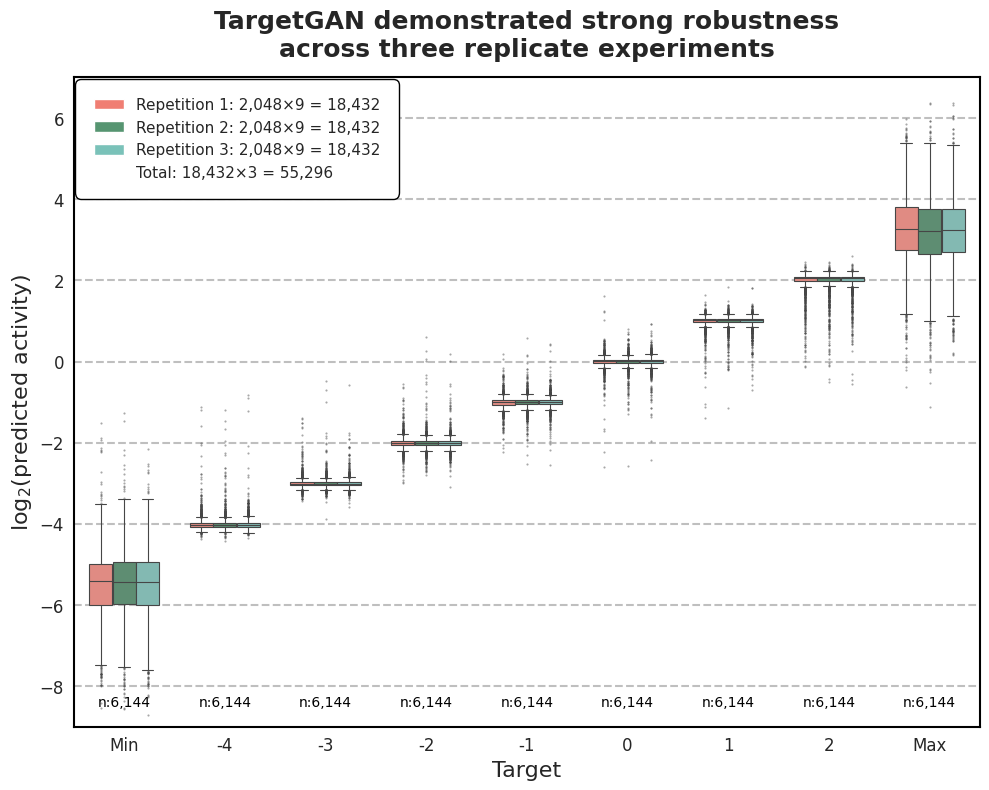

In [8]:
# --- Robustness Analysis (Seeds 2023, 2024, 2025) ---
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

# Config
seeds = ['2023', '2024', '2025']
rep_names = ['Repetition 1', 'Repetition 2', 'Repetition 3'] # Corrected spelling
targets_order = ['min', '-4', '-3', '-2', '-1', '0', '1', '2', 'max']
x_tick_labels = ['Min', '-4', '-3', '-2', '-1', '0', '1', '2', 'Max']
colors_list = ['#F07E73', # Salmon
               '#569571', # Green
               '#7AC2B9'] # Teal/Light Blue (Matching image approx)

data_rows = []

print("Gathering data from replicates...")

for t_idx, prefix in enumerate(targets_order):
    for s_idx, seed in enumerate(seeds):
        # Construct path
        folder = f"target_{prefix}_seed_{seed}"
        path = os.path.join(logs_dir, folder, 'last_seq.txt')
        
        preds = []
        if os.path.exists(path):
            with open(path, 'r') as f:
                # Filter empty lines
                seqs = [line.strip() for line in f if line.strip()]
            
            if seqs:
                # Predict in batches
                # Reuse 'model' from previous cells
                one_hots = np.array([one_hot_encode(s) for s in seqs])
                preds = model.predict(one_hots, verbose=0, batch_size=2048).flatten()
        
        # Add to dataset
        for score in preds:
            data_rows.append({
                'Target': x_tick_labels[t_idx], # Use display label for grouping
                'Repetition': rep_names[s_idx],
                'Score': score,
                'SortIndex': t_idx # For sorting
            })

# Create DataFrame
df_rob = pd.DataFrame(data_rows)

if not df_rob.empty:
    print("Data loaded. Plotting...")
    
    plt.figure(figsize=(10, 8))
    sns.set_style("white")
    
    # Create Boxplot
    ax = sns.boxplot(data=df_rob, x='Target', y='Score', hue='Repetition', 
                     palette=colors_list, 
                     showfliers=True, 
                     flierprops={'marker': '.', 'markersize': 1, 'alpha': 0.5},
                     linewidth=0.8,
                     width=0.7)
    
    # Grid lines
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.5, linewidth=1.5)
    ax.set_axisbelow(True)
    
    # Titles and Labels
    plt.title('TargetGAN demonstrated strong robustness\nacross three replicate experiments', 
              fontsize=18, fontweight='bold', y=1.02)
    plt.xlabel('Target', fontsize=16)
    plt.ylabel('log$_2$(predicted activity)', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Calculate counts for Legend and Annotations
    counts = df_rob.groupby('Repetition')['Score'].count()
    rep_counts = [counts.get(r, 0) for r in rep_names]
    # Sample calculation string: "2,048x9 = 18,432"
    # Assuming standard count. If counts vary, this might be approximate text.
    # We'll use the first target of the first rep to guess the specific batch size if needed, 
    # or just use the total / 9.
    
    legend_texts = []
    total_samples = sum(rep_counts)
    for i, r_name in enumerate(rep_names):
        c = rep_counts[i]
        # Infer individual batch size (approx)
        batch = c // 9 
        legend_texts.append(f"{r_name}: {batch:,}×9 = {c:,}")
    
    legend_texts.append(f"Total: {rep_counts[0]:,}×3 = {total_samples:,}")

    # Custom Legend Box
    handles = [Patch(facecolor=colors_list[i], label=legend_texts[i]) for i in range(3)]
    # Add invisible handle for Total
    from matplotlib.lines import Line2D
    handles.append(Line2D([0], [0], color='none', label=legend_texts[3]))
    
    leg = ax.legend(handles=handles, loc='upper left', fontsize=11, 
                    frameon=True, edgecolor='black', framealpha=1, borderpad=0.8)
    leg.get_frame().set_boxstyle("Round,pad=0.4")
    
    # Annotate 'n: ...' at the bottom of each group
    # We need the count per target (summing all reps)
    total_per_target = df_rob.groupby('Target')['Score'].count()
    # Sort by the x-axis order
    target_ns = [total_per_target.get(t, 0) for t in x_tick_labels]
    
    # Get y-axis limits to position text
    y_min, y_max = ax.get_ylim()
    # Position slightly above the bottom spine or at specific data coord
    # Image shows labels just above the x-axis labels. 
    # Let's verify the data range. Min target looks like -8ish.
    # We can place text at y = -7.5 roughly if data goes to -8.
    
    text_y_pos = y_min + (y_max - y_min) * 0.02 # Just above bottom
    # Or fixed if we know the scale. Let's try to find a gap.
    # Actually, seaborn/mpl puts labels outside? No, inside in the reference image.
    
    # Adjust Y limit to make room for annotations if needed
    ax.set_ylim(bottom=-9, top=7) 
    
    for i, count in enumerate(target_ns):
        ax.text(i, -8.5, f"n:{count:,}", ha='center', fontsize=10, color='black')

    # Border frame
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

    plt.tight_layout()
    plt.show()
else:
    print("No data found for the specified seeds and targets.")

## 3.4. K-mer Frequency Correlation between NPs and SPs

Counts - Natural: 76851, Synthetic: 55296


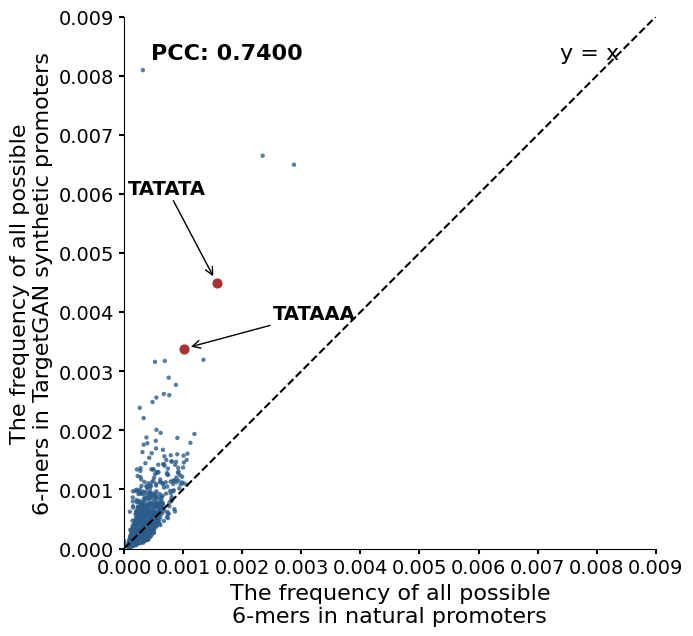

In [1]:
from utils import accumulate_kmer_frequencies
from functools import reduce
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

# 1. Load Data
natural_path = '../data/Natural promoters.xlsx'
target_path = '../data/targetgan_55296.xlsx'

# Read Excel Files
df_nat = pd.read_excel(natural_path)
df_syn = pd.read_excel(target_path)


# Synthetic: User confirmed column is 'sequence'
# Natural: Using all NPs as requested, assuming 'sequence' column exists
natural_seqs = list(df_nat.sequence.dropna())
generated_seqs = list(df_syn.sequence.dropna())

print(f"Counts - Natural: {len(natural_seqs)}, Synthetic: {len(generated_seqs)}")

# 2. Calculate 6-mer Frequencies
k = 6
accumulated_vector_natural = accumulate_kmer_frequencies(natural_seqs, k)
accumulated_vector_generated = accumulate_kmer_frequencies(generated_seqs, k)

# 3. Calculate Pearson Correlation
pcc, _ = pearsonr(accumulated_vector_natural, accumulated_vector_generated)

# 4. Identify indices for TATA boxes
bases = ['A', 'T', 'C', 'G']
kmer_all = reduce(lambda x,y: [i+j for i in x for j in y], [bases] * k)
idx_tataaa = kmer_all.index('TATAAA')
idx_tatata = kmer_all.index('TATATA')

# 5. Plotting
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')

# Scatter Plot
ax.scatter(accumulated_vector_natural, accumulated_vector_generated, 
           s=10, c='#2b5c8a', alpha=0.8, edgecolors='none', label='6-mers')

# Diagonal Line
limit = 0.009 # Limit adjusted to cover the full range of all NPs
ax.plot([0, limit], [0, limit], 'k--', linewidth=1.5, label='y = x')

# Highlight TATA
highlight_color = '#a83232'
# Use indices to get coordinates
x_tataaa, y_tataaa = accumulated_vector_natural[idx_tataaa], accumulated_vector_generated[idx_tataaa]
x_tatata, y_tatata = accumulated_vector_natural[idx_tatata], accumulated_vector_generated[idx_tatata]

ax.scatter(x_tataaa, y_tataaa, s=40, c=highlight_color, zorder=10)
ax.scatter(x_tatata, y_tatata, s=40, c=highlight_color, zorder=10)

# Annotations
ax.text(0.05, 0.92, f'PCC: {pcc:.4f}', transform=ax.transAxes, fontsize=16, fontweight='bold')
ax.text(0.82, 0.92, 'y = x', transform=ax.transAxes, fontsize=16)

# Arrows
ax.annotate('TATAAA', 
            xy=(x_tataaa, y_tataaa), 
            xytext=(x_tataaa + 0.0015, y_tataaa + 0.0005),
            fontsize=14, fontweight='bold',
            arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=0, shrinkB=5))

ax.annotate('TATATA', 
            xy=(x_tatata, y_tatata), 
            xytext=(x_tatata - 0.0015, y_tatata + 0.0015),
            fontsize=14, fontweight='bold',
            arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=0, shrinkB=5))

# Labels and Title
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_xlabel('The frequency of all possible\n6-mers in natural promoters', fontsize=16)
ax.set_ylabel('The frequency of all possible\n6-mers in TargetGAN synthetic promoters', fontsize=16)
# ax.set_title('6-mer Frequency Correlation', fontsize=20, fontweight='bold', pad=20)

sns.despine()
ax.tick_params(width=1.5, labelsize=14)

plt.tight_layout()
plt.show()

## 3.5. Sequence Diversity (Jaccard, Levenshtein) and GC Content Analysis

Loading sequences and calculating GC...
Loading distance matrices...
Sample counts: [76851, 76851, 55296]


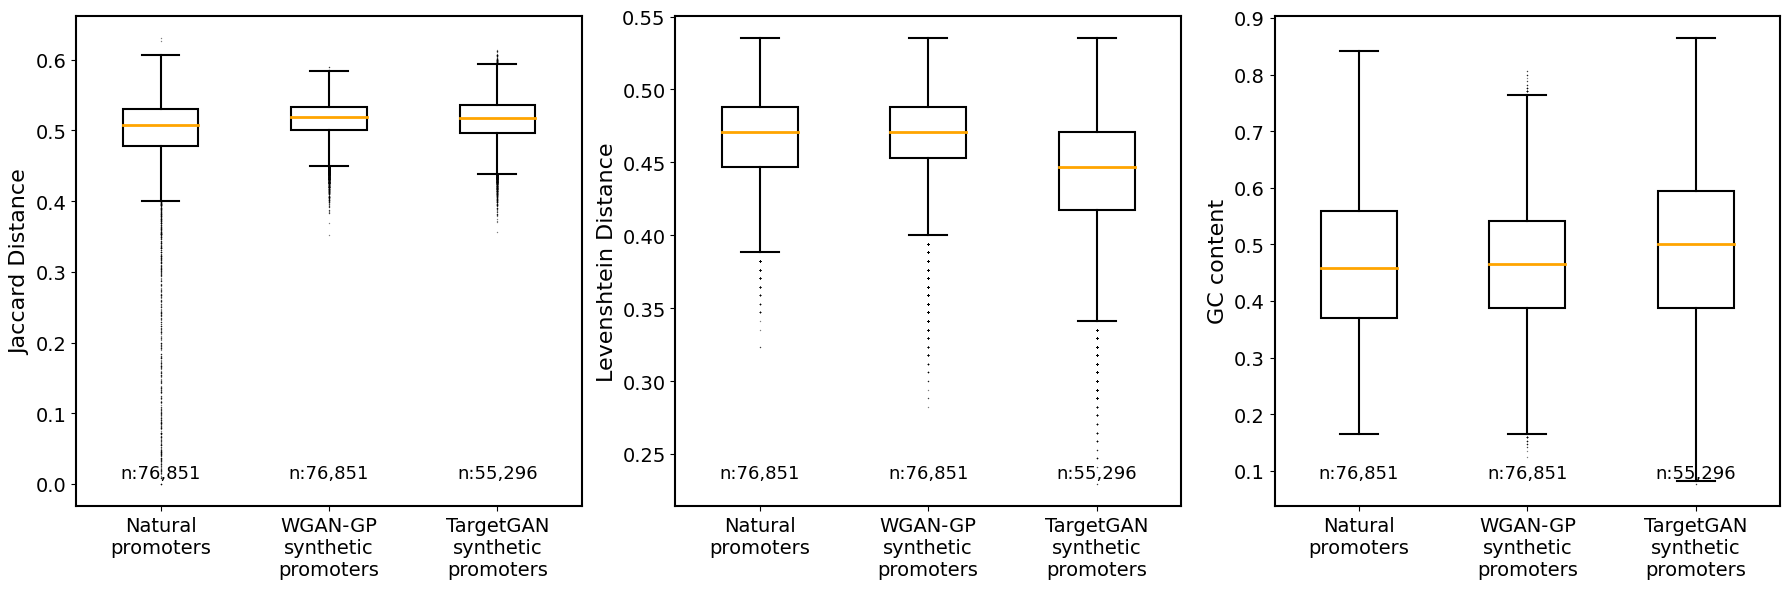

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import utils
importlib.reload(utils)
from utils import gc_content
import os

# --- 1. Load Data ---

# Paths for Distances (User provided)
paths = {
    'jaccard': {
        'Natural': './data_for_plot/test_jaccard.npy',
        'WGAN-GP': './data_for_plot/wgan_jaccard.npy',
        'TargetGAN': './data_for_plot/targetgan_jaccard.npy'
    },
    'levenshtein': {
        'Natural': './data_for_plot/test_Levenshtein.npy',
        'WGAN-GP': './data_for_plot/wgan_Levenshtein.npy',
        'TargetGAN': './data_for_plot/targetgan_Levenshteinnpy' # Note: typo in filename on disk
    }
}

# Paths for Sequences (For GC Content)
nat_file = '../data/Natural promoters.xlsx'
wgan_file = '../samples/WGAN-GP-54000-76851.txt'
target_file = '../data/targetgan_55296.xlsx'

# Load Sequence Data and Calculate GC
print("Loading sequences and calculating GC...")
gc_data = []

# Natural
if os.path.exists(nat_file):
    df_nat = pd.read_excel(nat_file)
    seq_nat = df_nat['sequence'].dropna().tolist()
    gc_data.append([gc_content(s) for s in seq_nat])
else:
    print(f"File not found: {nat_file}")
    gc_data.append([])

# WGAN-GP
if os.path.exists(wgan_file):
    with open(wgan_file, 'r') as f:
        seq_wgan = [line.strip() for line in f if line.strip()]
    gc_data.append([gc_content(s) for s in seq_wgan])
else:
    print(f"File not found: {wgan_file}")
    gc_data.append([])

# TargetGAN
if os.path.exists(target_file):
    df_target = pd.read_excel(target_file)
    seq_target = df_target['sequence'].dropna().tolist()
    gc_data.append([gc_content(s) for s in seq_target])
else:
    print(f"File not found: {target_file}")
    gc_data.append([])

# Load Distance Data
print("Loading distance matrices...")
def load_npy_safe(p):
    if os.path.exists(p):
        return np.load(p)
    else:
        print(f"File not found: {p}")
        return []

jac_data = [load_npy_safe(paths['jaccard'][k]) for k in ['Natural', 'WGAN-GP', 'TargetGAN']]
lev_data = [load_npy_safe(paths['levenshtein'][k]) for k in ['Natural', 'WGAN-GP', 'TargetGAN']]

# Setup labels and counts
counts = [len(g) for g in gc_data]
labels = ['Natural\npromoters', 'WGAN-GP\nsynthetic\npromoters', 'TargetGAN\nsynthetic\npromoters']

print(f"Sample counts: {counts}")

# --- 2. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Style settings
boxprops = dict(facecolor='white', edgecolor='black', linewidth=1.5)
medianprops = dict(color='orange', linewidth=2)
whiskerprops = dict(color='black', linewidth=1.5)
capprops = dict(color='black', linewidth=1.5)
# Using 'o' marker for fliers with small size
flierprops = dict(marker='o', markersize=1, markerfacecolor='black', markeredgecolor='none', alpha=0.5)

def plot_custom_boxplot(ax, data, ylabel):
    # Create boxplot
    bp = ax.boxplot(data, 
                    labels=labels, 
                    patch_artist=True,
                    showfliers=True,
                    boxprops=boxprops,
                    medianprops=medianprops,
                    whiskerprops=whiskerprops,
                    capprops=capprops,
                    flierprops=flierprops,
                    widths=0.45) # width 0.45 looks similar to image
    
    # Axis labels and ticks
    ax.set_ylabel(ylabel, fontsize=16)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    # Border
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')
    
    # Annotate counts inside the plot at bottom
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    y_pos = ymin + yrange * 0.05 # 5% from bottom
    
    for i, n in enumerate(counts):
        ax.text(i+1, y_pos, f"n:{n:,}", ha='center', va='bottom', fontsize=13, color='black')

# Plot 1: Jaccard
plot_custom_boxplot(axes[0], jac_data, 'Jaccard Distance')

# Plot 2: Levenshtein
plot_custom_boxplot(axes[1], lev_data, 'Levenshtein Distance')

# Plot 3: GC Content
plot_custom_boxplot(axes[2], gc_data, 'GC content')

plt.tight_layout()
plt.show()